# Lab 13：把故事模型變成 embedding 模型

對應講義：[第 13 課](../lessons/13_embedding_models.md)

需要 Lab 06 的 `checkpoints/base_model.pt`。

**任務**：1,000 篇驗證故事，每篇切成前後兩半。用前半段當查詢，在 1,000 個後半段裡找出**同一篇**的後半段。前後兩半講的是同一群角色、同一件事，但用字不同——這需要「意思」上的相似，而不只是關鍵字。

1. 基線：BM25（式 13.4）、word2vec 平均（第 02 課）
2. 沒有對比訓練的語言模型：mean pooling vs last-token pooling（§2.2），以及它的「各向異性」
3. 對比訓練（InfoNCE，式 13.1；independent cropping，§2.5）
4. alignment 與 uniformity（式 13.2）
5. Matryoshka（式 13.3）：截短向量還能用嗎？

CPU 約 23 分鐘（四次對比訓練各約 5.5 分鐘）。

In [1]:
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

In [2]:
from lm_course.artifacts import course_stories, course_tokenizer, load_base_model
from lm_course.embeddings import split_halves

tok = course_tokenizer()
base = load_base_model()
train_stories, val_stories = course_stories()
eval_stories = [s for s in val_stories if len(s.split()) >= 60][:1000]
queries, docs = map(list, zip(*[split_halves(s) for s in eval_stories]))
MAX_TOKENS = 128
print(f"{len(queries)} query/document pairs")
print("query   :", queries[0][:200])
print("document:", docs[0][:200])

1000 query/document pairs
query   : One day, a little cricket was in the garden. He liked to jump and play. The sun was shining and the sky was blue. The cricket was happy because he had a lot of space to play. Soon, it started to rain.
document: The cricket was now safe from the rain. After the rain, the cricket went to play again. He saw a friend, a ladybug. She was looking for food. The cricket told her about the big leaf. They both went to


## 1. 基線

In [3]:
from lm_course.embeddings import alignment_and_uniformity, average_word_vectors, bm25_scores, retrieval_metrics
from lm_course.word2vec import build_vocab, encode_sentences, train_skipgram, words_from_text

results = {}
results["BM25"] = retrieval_metrics(bm25_scores(queries, docs))

sentences = [words_from_text(s) for s in train_stories]
vocab = build_vocab(sentences, min_count=10)
w2v = train_skipgram(encode_sentences(sentences, vocab), vocab, dim=64, window=4, epochs=1, batch_size=8192, log_every=0)
wq = average_word_vectors(queries, w2v.model.embeddings(), vocab.index)
wd = average_word_vectors(docs, w2v.model.embeddings(), vocab.index)
results["word2vec average"] = retrieval_metrics(wq @ wd.T)
for name, m in results.items():
    print(f"{name:<22} " + "  ".join(f"{k} {v:.3f}" for k, v in m.items()))

BM25                   recall@1 0.824  recall@10 0.960  mrr 0.876
word2vec average       recall@1 0.168  recall@10 0.386  mrr 0.246


## 2. 還沒有對比訓練的語言模型

In [4]:
from lm_course.embeddings import TextEncoder

vectors = {}
for pooling in ("mean", "last"):
    encoder = TextEncoder(copy.deepcopy(base), pooling=pooling)
    q, d = encoder.encode(tok, queries, MAX_TOKENS), encoder.encode(tok, docs, MAX_TOKENS)
    vectors[f"pretrained, {pooling}"] = (q, d)
    results[f"pretrained, {pooling}"] = retrieval_metrics(q @ d.T)
for name in ("pretrained, mean", "pretrained, last"):
    q, d = vectors[name]
    sims = (q @ d.T)
    off_diag = sims[~torch.eye(len(q), dtype=torch.bool)]
    print(f"{name:<22} " + "  ".join(f"{k} {v:.3f}" for k, v in results[name].items())
          + f"   | cosine of unrelated pairs: mean {off_diag.mean():.2f}")

pretrained, mean       recall@1 0.344  recall@10 0.667  mrr 0.450   | cosine of unrelated pairs: mean 0.39
pretrained, last       recall@1 0.086  recall@10 0.253  mrr 0.143   | cosine of unrelated pairs: mean 0.23


沒有對比訓練時，隨便兩段不相關的文字，餘弦相似度平均也有 0.39（mean pooling；隨機方向應該是 0）——向量擠在一個窄錐裡（各向異性，講義 §4）。排名仍然有一點訊號，但遠不如 BM25。last-token pooling 更差：沒訓練過的模型，最後一個 token 的狀態忙著預測下一個字，不是在總結整段。

## 3. 對比訓練

從**訓練**故事裡隨機抽 64 篇，每篇獨立裁出兩個片段（各佔 20%–50% 的字）當正例，其餘 63 篇的片段是負例（in-batch negatives）；對稱的 InfoNCE，溫度 0.05。從預訓練模型開始，也比較「從隨機初始化開始」。

In [5]:
from lm_course.artifacts import base_model_config
from lm_course.embeddings import train_contrastive
from lm_course.model import GPT

STEPS = 300
trained = {}
for name, backbone, pooling in [
    ("contrastive, mean", copy.deepcopy(base), "mean"),
    ("contrastive, last", copy.deepcopy(base), "last"),
    ("contrastive from scratch, mean", GPT(base_model_config()), "mean"),
]:
    set_seed(0)
    encoder = TextEncoder(backbone, pooling=pooling)
    r = train_contrastive(encoder, tok, train_stories, num_steps=STEPS, batch_size=64, max_tokens=MAX_TOKENS, lr=3e-4, log_every=0)
    q, d = encoder.encode(tok, queries, MAX_TOKENS), encoder.encode(tok, docs, MAX_TOKENS)
    trained[name] = encoder
    vectors[name] = (q, d)
    results[name] = retrieval_metrics(q @ d.T)
    print(f"{name:<32} " + "  ".join(f"{k} {v:.3f}" for k, v in results[name].items()) + f"   ({r.seconds / 60:.1f} min, final loss {np.mean(r.losses[-20:]):.2f})")

contrastive, mean                recall@1 0.823  recall@10 0.972  mrr 0.881   (5.7 min, final loss 0.16)


contrastive, last                recall@1 0.844  recall@10 0.957  mrr 0.885   (5.6 min, final loss 0.20)


contrastive from scratch, mean   recall@1 0.372  recall@10 0.752  mrr 0.494   (5.6 min, final loss 0.69)


In [6]:
print(f"{'method':<32}{'recall@1':>10}{'recall@10':>11}{'MRR':>8}")
for name, m in results.items():
    print(f"{name:<32}{m['recall@1']:>10.3f}{m['recall@10']:>11.3f}{m['mrr']:>8.3f}")

method                            recall@1  recall@10     MRR
BM25                                 0.824      0.960   0.876
word2vec average                     0.168      0.386   0.246
pretrained, mean                     0.344      0.667   0.450
pretrained, last                     0.086      0.253   0.143
contrastive, mean                    0.823      0.972   0.881
contrastive, last                    0.844      0.957   0.885
contrastive from scratch, mean       0.372      0.752   0.494


對比訓練 300 步後，mean 與 last-token pooling 都追平了 BM25（recall@1 約 0.82–0.84），而且 last-token 不再比較差：訓練教會了最後一個位置「總結整段」。從隨機初始化開始、同樣訓練 300 步的模型只有 0.37——預訓練學到的語言知識是 embedding 模型的地基。

## 4. alignment 與 uniformity

對每種向量量式 (13.2)：alignment（正例之間的距離平方，越小越好）與 uniformity（越小代表越散開）。

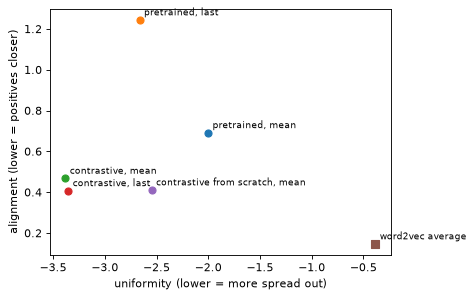

In [7]:
plt.figure(figsize=(5.5, 4))
for name, (q, d) in vectors.items():
    align, uniform = alignment_and_uniformity(q, d)
    plt.scatter(uniform, align, s=40)
    plt.annotate(name, (uniform, align), fontsize=8, xytext=(4, 4), textcoords="offset points")
align, uniform = alignment_and_uniformity(wq, wd)
plt.scatter(uniform, align, s=40, marker="s")
plt.annotate("word2vec average", (uniform, align), fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.xlabel("uniformity (lower = more spread out)")
plt.ylabel("alignment (lower = positives closer)")
plt.show()

- **word2vec 平均**在右下角：alignment 最小、uniformity 最大——每篇故事都充滿 the、was、a，平均出來的向量全擠在一起。正例很近，但其他東西也一樣近，所以分不出誰是誰：這就是講義 §2.4 說的「只顧 alignment 會塌縮」的樣子。
- **預訓練模型**比較散開，但正例之間反而比較遠（last-token 尤其明顯）。
- **對比訓練**同時改善兩者：向量更散開（uniformity 變小），正例也更接近（alignment 變小）。從隨機初始化開始的版本 alignment 差不多，但散得不夠開。

## 5. Matryoshka

同樣的設定再訓練一次，loss 改成前 16、32、64、128、256 維的 InfoNCE 平均（式 13.3）。比較兩個模型把向量**截短**到前 $k$ 維後的檢索表現。

first  16 dims: recall@1 standard 0.453, Matryoshka 0.642
first  32 dims: recall@1 standard 0.683, Matryoshka 0.764
first  64 dims: recall@1 standard 0.754, Matryoshka 0.784
first 128 dims: recall@1 standard 0.809, Matryoshka 0.797
first 256 dims: recall@1 standard 0.823, Matryoshka 0.813


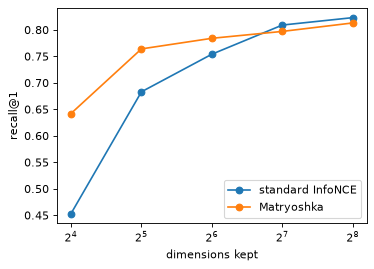

In [8]:
import torch.nn.functional as F

DIMS = [16, 32, 64, 128, 256]
set_seed(0)
mrl = TextEncoder(copy.deepcopy(base), pooling="mean")
r = train_contrastive(mrl, tok, train_stories, num_steps=STEPS, batch_size=64, max_tokens=MAX_TOKENS, lr=3e-4, matryoshka_dims=DIMS, log_every=0)
qm, dm = mrl.encode(tok, queries, MAX_TOKENS), mrl.encode(tok, docs, MAX_TOKENS)
qs, ds = vectors["contrastive, mean"]
rows = []
for k in DIMS:
    plain = retrieval_metrics(F.normalize(qs[:, :k], dim=-1) @ F.normalize(ds[:, :k], dim=-1).T)["recall@1"]
    matry = retrieval_metrics(F.normalize(qm[:, :k], dim=-1) @ F.normalize(dm[:, :k], dim=-1).T)["recall@1"]
    rows.append((k, plain, matry))
    print(f"first {k:3d} dims: recall@1 standard {plain:.3f}, Matryoshka {matry:.3f}")
plt.figure(figsize=(5, 3.5))
plt.semilogx([k for k, _, _ in rows], [p for _, p, _ in rows], "o-", base=2, label="standard InfoNCE")
plt.semilogx([k for k, _, _ in rows], [m for _, _, m in rows], "o-", base=2, label="Matryoshka")
plt.xlabel("dimensions kept")
plt.ylabel("recall@1")
plt.legend()
plt.show()

一般訓練的向量，資訊散在所有維度，截短就掉很多（16 維時 recall@1 從 0.82 掉到 0.45）；Matryoshka 把重要的資訊擠到前面，前 32 維就保留了完整向量約 94% 的效果——儲存與搜尋成本可以砍到 1/8。代價是用滿 256 維時略差一點（0.81 vs 0.82）。

## 小結

- 語言模型的隱藏狀態直接平均，是很差的句子 embedding（各向異性）；幾分鐘的對比訓練就大幅改善。
- 預訓練過的骨幹比從隨機初始化開始好得多——這是 2024 年起 LLM 當 embedding 骨幹的原因。
- 在這個任務上 BM25 是很強的對手：故事的前後兩半共用角色名字等關鍵字，對比訓練後才追平它。實務上常把兩者合用（hybrid search）。

下一步：[第 14 課](../lessons/14_evaluation_and_nanochat.md)。